# Day 3 — When Do New Yorkers Complain?

**Theme:** One clean datetime column unlocks time-based questions that raw strings can't answer.

**By the end of this notebook you will have:**
- Re-applied your three Day 2 cleaning functions (from memory this time)
- Extracted day-of-week and hour-of-day from `created_dt`
- Used `groupby` to count complaints by type, by day, and by hour
- Produced your first bar chart

**Rules:** Write every line yourself. No asking for hints — figure out the error first.

In [47]:
import pandas as pd

df = pd.read_csv('../data/311_cleaned.csv')

df['created_dt'] = pd.to_datetime(df['created_dt'])





# You wrote all of this yesterday — try it from memory before looking back at day02.


## Step 1 — Top complaint types

Before we look at time, let's confirm what the most common complaints are in your dataset.
Use `complaint_type_clean` — not the raw column — so the counts are accurate.

In [48]:
print(df['complaint_type_clean'])


0                       Illegal Parking
1           Non-Emergency Police Matter
2                     Abandoned Vehicle
3                   Noise - Residential
4                   Noise - Residential
                      ...              
106397              Noise - Residential
106398               Noise - Commercial
106399                 Blocked Driveway
106400    Emergency Response Team (Ert)
106401              Noise - Residential
Name: complaint_type_clean, Length: 106402, dtype: str


## Step 2 — Extract time features

A datetime column has a `.dt` accessor — it lets you pull out parts of the date.
For example: `df['created_dt'].dt.hour` gives you the hour (0–23) for every row.

Create two new columns:
- `day_of_week` — the name of the day (Monday, Tuesday, …)
- `hour` — the hour of day as an integer (0–23)

In [49]:
df['day_of_week'] = df['created_dt'].dt.day_of_week

df['hour'] = df['created_dt'].dt.hour




print(df['created_dt'].dt.day_of_week)
print(df['created_dt'].dt.hour)


0         6
1         6
2         6
3         6
4         6
         ..
106397    4
106398    4
106399    4
106400    4
106401    4
Name: created_dt, Length: 106402, dtype: int32
0         23
1         23
2         23
3         23
4         23
          ..
106397     0
106398     0
106399     0
106400     0
106401     0
Name: created_dt, Length: 106402, dtype: int32


## Step 3 — Complaints by day of week

`groupby` works like a pivot table: split the DataFrame into groups, apply a calculation to each group, combine the results.

Group by `day_of_week` and count the rows in each group.

In [50]:
hourly_counts = (df.groupby('hour').size())
print(hourly_counts)


hour
0     3723
1     2334
2     1545
3     1129
4     1061
5     1343
6     2496
7     4059
8     5894
9     6548
10    6408
11    6084
12    5879
13    5470
14    5443
15    5490
16    5044
17    5139
18    5084
19    5131
20    4989
21    5474
22    6047
23    4588
dtype: int64


## Step 4 — Complaints by hour of day

Same pattern as Step 3, different column.

In [51]:
# Group by hour, count complaints, store in hourly_counts.
# Print it.


## Step 5 — Your first bar chart

pandas can plot directly from a Series: `my_series.plot(kind='bar')`.

You'll also need this line at the top of the cell to make the chart appear in the notebook:
```python
import matplotlib.pyplot as plt
```
And this line at the bottom to display it:
```python
plt.show()
```

Plot whichever result interests you more — by day or by hour.

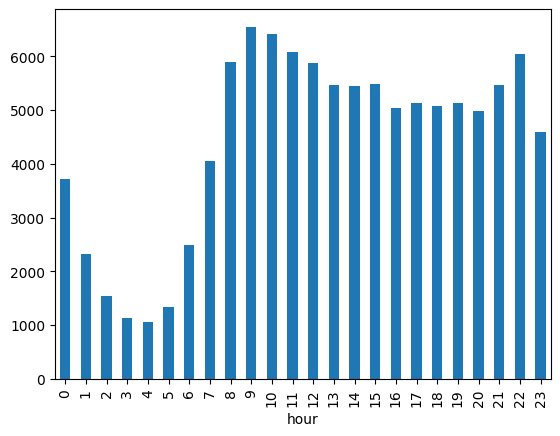

In [52]:
import matplotlib.pyplot as plt
hourly_counts.plot(kind='bar')

plt.show()


## Day 3 Recap

| What you did | Why it matters |
|---|---|
| `.dt.day_name()` / `.dt.hour` | Extracted parts of a datetime for grouping |
| `groupby` + `.count()` | Summarized rows by a category — the core of any analysis |
| `.plot(kind='bar')` | Turned a number into something a person can read in 2 seconds |

### What's coming on Day 4

We'll bring in a second dataset — a slice of NYC PLUTO — and join it to the 311 data by zip code.
That introduces `merge`, the pandas version of a database JOIN.